# Delivery Lead-Time Regression EDA

**IT5006 · Milestone 1 · Updated 2026-09-11**

**Candidate question:** at order placement, how many days will an order take to reach the customer, and can a later regression model improve on using the promised duration directly?

This notebook consumes the shared **v2** table produced by Notebook `00`. The common dataset overview, raw-table joins, general temporal patterns and entity distributions are covered there; this notebook focuses on the delivery-duration candidate problem. It contains descriptive EDA and an untrained prediction rule, with no learned model or held-out evaluation.

## Problem Scoping Checklist

| Course check | Assessment for delivery lead-time regression |
|---|---|
| **1. Derivable target** | Yes. Compute `(actual delivery timestamp − purchase timestamp) / 86400` in fractional days from fields already in v2. No external data is required. |
| **2. Realistic features** | Use the purchase-time roles in `00` §6.2: location/distance, order contents, quoted freight and the estimated delivery date. The quoted promise is a baseline and candidate input. Actual delivery, final status, reviews and outcome-derived labels are excluded from predictors; payments are not used here. Phase 2 must preserve the promise and feature values known at prediction time. |
| **3. Sufficient signal** | The primary sample shows associations with maximum observed distance (ρ≈0.541), promised duration (ρ≈0.522) and freight (ρ≈0.382), plus route/time variation. These justify further investigation, not an accuracy claim; the direct-promise rule is evaluated below. |
| **4. Manageable imbalance** | There are no class labels to rebalance. The relevant issue is a right-tailed continuous target: retain valid long deliveries, use MAE as the primary criterion, and report RMSE plus tail errors. Compare raw-target and `log1p`/robust-loss candidates only within Phase 2 training/validation, assessing final errors in days. |
| **5. Clear stakeholder** | Fulfilment planning and customer-service teams can use an order-time duration estimate to plan follow-up and communicate an expected arrival date. The evidence covers observed completed deliveries; cancellations and still-undelivered orders need separate treatment. |

## Context & Methods

The target is **purchase-to-delivery duration**, not days late relative to the promise. Timestamps are timezone-naive; no timezone conversion is imposed.

- Reuse `00`'s `to_order_level()` aggregation unchanged. Monetary sums, counts, maximum observed distance and all-sellers-same-state have the same definitions as the shared foundation.
- v2 stores integer `delivery_days` and `promised_days` using `.dt.days`. Preserve these fields for reconciliation, and compute `lead_time_days` / `promised_lead_time_days` from the same timestamps without discarding fractions of a day. Integer and fractional results are explicitly distinguished below.
- The primary cohort requires `order_status == delivered`, valid purchase/actual delivery timestamps and non-negative elapsed time. No upper-duration cutoff is imposed. The 775 orders without items are absent from v2 by construction and are documented in `00`; they cannot be recovered from this input.
- All-sellers-same-state is an order-level relation. Distance is the maximum **observed** great-circle distance between customer/seller zip centroids, not an actual road route. Four primary orders have only partial item-distance coverage; 476 have none.
- Keep shared raw total weight unchanged. An additional average item-weight candidate is missing when any item lacks positive valid weight. English categories remain missing when unknown/untranslated; mixed and incomplete orders receive explicit groups for the category panel.

## 1. Read v2 and define the analysis cohort

First unpack the course CSVs into `data/Olist_CSV/` and run **`00_dataset_overview_eda.ipynb`** to generate `data/smartcommerce_consolidated_v2.csv`. Raw-data construction is not repeated here. Run this notebook from the repository root or `notebooks/`, or set `V2_CSV` / `OLIST_V2_CSV` explicitly.

Dependencies: pandas, NumPy, Matplotlib, SciPy and IPython. Verified here with Python 3.12, pandas 2.2.3, NumPy 2.3.5, Matplotlib 3.10.9 and SciPy 1.18.1. The shared `00` additionally requires Seaborn; its existing plotting syntax needs Matplotlib below 3.11 in this environment.

All generated CSVs, figures and evidence are written under the git-ignored `data/03_delivery_regression_outputs/` by default. An optional `DELIVERY_EDA_OUTPUT_DIR` override supports local review. Neither raw data nor the consolidated table should be committed.

In [1]:
from pathlib import Path
import os
import hashlib
import importlib.metadata
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Image

pd.options.display.float_format = '{:,.3f}'.format
BLUE, GOLD, INK, GREY = '#3268A8', '#C49A32', '#263445', '#D9DFE6'
NUMERIC_FEATURES = ['max_distance_km','promised_lead_time_days','total_freight','total_price',
                    'freight_ratio','avg_product_weight_g','item_count','seller_count']
SOURCE_COMMIT = 'b0bcc909f085945ad41cebaf86581a3f58a050ec'

def find_v2_path(explicit=None):
    """Locate only the shared v2 CSV; raw-data preparation belongs to Notebook 00."""
    if explicit is not None:
        path = Path(explicit).expanduser()
        if path.is_file():
            return path
        raise FileNotFoundError('Configured v2 CSV does not exist. Run Notebook 00 first.')
    configured = os.environ.get('OLIST_V2_CSV')
    if configured:
        return find_v2_path(configured)
    here = Path.cwd()
    candidates = [here/'data/smartcommerce_consolidated_v2.csv',
                  here.parent/'data/smartcommerce_consolidated_v2.csv']
    for path in candidates:
        if path.is_file():
            return path
    raise FileNotFoundError('Run 00_dataset_overview_eda.ipynb to build data/smartcommerce_consolidated_v2.csv, '
                            'then run 03 from the repository root or notebooks/. Alternatively set OLIST_V2_CSV.')

# Optionally set V2_CSV = Path("path/to/smartcommerce_consolidated_v2.csv").
V2_CSV = None
V2_PATH = find_v2_path(V2_CSV)
OUTPUT_DIR = Path(os.environ.get('DELIVERY_EDA_OUTPUT_DIR',str(V2_PATH.parent/'03_delivery_regression_outputs')))
for folder in ['tables','data','figures']:
    (OUTPUT_DIR/folder).mkdir(parents=True,exist_ok=True)
BASE = OUTPUT_DIR
print('Input:', V2_PATH.name)

Input: smartcommerce_consolidated_v2.csv


### Shared order aggregation and regression-specific fields

The following helper is reproduced from `00`, cell 45. Input checks ensure item-key uniqueness and consistency of attributes copied across an order's items. The regression extension adds fractional targets, quality flags and display groups without changing the shared fields. Familiar aliases are used in plots: `basket_value → total_price`, `freight → total_freight`, `n_items → item_count`, `n_sellers → seller_count`.

In [2]:
def load_v2(path):
    """Read the shared item table and check the columns used by the common aggregation."""
    dates = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
    frame = pd.read_csv(path, parse_dates=dates)
    needed = {'order_id','order_item_id','seller_id','order_status','customer_unique_id',
              'customer_state','seller_state','product_category_name_english','product_weight_g',
              'price','freight_value','distance_km','same_state','promised_days','delivery_days',
              'payment_total','payment_max_installments','main_payment_type','review_score', *dates}
    assert needed.issubset(frame.columns), 'Input is not the expected v2 table.'
    assert frame[['order_id','order_item_id']].notna().all().all()
    assert not frame.duplicated(['order_id','order_item_id']).any(), 'Repeated item keys inflate orders.'
    if not pd.api.types.is_bool_dtype(frame.same_state):
        normalized = frame.same_state.astype('string').str.lower()
        assert normalized.isin(['true','false']).all(), 'Invalid same_state values.'
        frame['same_state'] = normalized.map({'true':True,'false':False}).astype(bool)
    assert frame.same_state.eq(frame.customer_state.eq(frame.seller_state)).all()
    # First-value aggregations are safe only when true order attributes are invariant across items.
    invariant = ['order_status','customer_unique_id','customer_state',*dates,
                 'promised_days','delivery_days','payment_total','payment_max_installments',
                 'main_payment_type','review_score']
    assert frame.groupby('order_id')[invariant].nunique(dropna=False).le(1).all().all()
    assert np.isfinite(frame[['price','freight_value']].to_numpy()).all()
    assert frame[['price','freight_value']].ge(0).all().all()
    return frame


def to_order_level(frame):
    """Collapse the item-grain table to one row per order, consistently across notebooks."""
    return (frame.groupby("order_id").agg(
        order_status=("order_status", "first"),
        purchase_ts=("order_purchase_timestamp", "first"),
        delivered_ts=("order_delivered_customer_date", "first"),
        estimated_ts=("order_estimated_delivery_date", "first"),
        customer_unique_id=("customer_unique_id", "first"),
        customer_state=("customer_state", "first"),
        seller_state=("seller_state", "first"),
        n_items=("order_item_id", "size"),
        n_sellers=("seller_id", "nunique"),
        n_categories=("product_category_name_english", "nunique"),
        basket_value=("price", "sum"),
        freight=("freight_value", "sum"),
        total_weight_g=("product_weight_g", "sum"),
        max_distance_km=("distance_km", "max"),
        all_same_state=("same_state", "all"),
        promised_days=("promised_days", "first"),
        delivery_days=("delivery_days", "first"),
        payment_total=("payment_total", "first"),
        payment_max_installments=("payment_max_installments", "first"),
        main_payment_type=("main_payment_type", "first"),
        review_score=("review_score", "first"),
    ).reset_index())


def prepare_orders(items):
    """Use the shared helper, then add explicit regression-only target and quality fields."""
    frame = to_order_level(items)
    g = items.groupby('order_id')
    extra = pd.DataFrame({
        'first_category':g.product_category_name_english.first(),
        'any_category_missing':g.product_category_name_english.count().lt(g.size()),
        'all_routes_known':items.customer_state.notna().mul(items.seller_state.notna()).groupby(items.order_id).all(),
        'any_distance_missing':g.distance_km.count().lt(g.size()),
        'first_cross_state':(~items.same_state).groupby(items.order_id).first(),
    })
    valid_weight = items.product_weight_g.where(items.product_weight_g.gt(0))
    extra['any_weight_missing'] = valid_weight.groupby(items.order_id).count().lt(g.size())
    extra['avg_product_weight_g'] = valid_weight.groupby(items.order_id).mean().mask(extra.any_weight_missing)
    frame = frame.merge(extra, on='order_id', how='left', validate='one_to_one')
    # Keep shared fields unchanged. Aliases preserve familiar names in the regression figures.
    aliases = {'purchase_ts':'order_purchase_timestamp','delivered_ts':'order_delivered_customer_date',
               'estimated_ts':'order_estimated_delivery_date','basket_value':'total_price',
               'freight':'total_freight','n_items':'item_count','n_sellers':'seller_count',
               'n_categories':'category_count'}
    for shared, alias in aliases.items():
        frame[alias] = frame[shared]
    frame['lead_time_days'] = (frame.delivered_ts-frame.purchase_ts).dt.total_seconds()/86400
    frame['promised_lead_time_days'] = (frame.estimated_ts-frame.purchase_ts).dt.total_seconds()/86400
    assert np.allclose(frame.delivery_days, np.floor(frame.lead_time_days), equal_nan=True)
    assert np.allclose(frame.promised_days, np.floor(frame.promised_lead_time_days), equal_nan=True)
    frame['any_cross_state'] = ~frame.all_same_state
    frame['route_group'] = np.select([~frame.all_routes_known,frame.any_cross_state],
                                     ['Unknown','Any seller cross-state'],default='All sellers same-state')
    frame['category_group'] = np.select([frame.any_category_missing,frame.n_categories.gt(1)],
                         ['Missing/incomplete category','Multiple categories'],default=frame.first_category)
    frame['is_primary'] = (frame.order_status.eq('delivered') & frame.lead_time_days.notna()
                           & frame.lead_time_days.ge(0))
    frame['is_date_observed_cohort'] = frame.delivered_ts.notna()
    frame['freight_ratio'] = frame.freight.div(frame.basket_value.where(frame.basket_value.gt(0)))
    frame['purchase_month'] = frame.purchase_ts.dt.to_period('M').astype(str)
    frame['purchase_weekday'] = frame.purchase_ts.dt.dayofweek
    primary = frame.loc[frame.is_primary].copy()
    primary['freight_quintile'] = pd.qcut(primary.total_freight,5,duplicates='drop')
    assert frame.order_id.is_unique and len(frame)==items.order_id.nunique()
    integrity = pd.DataFrame([
        ('Unique item keys',len(items),True),
        ('Unique order rows',len(frame),frame.order_id.is_unique),
        ('Primary order rows',len(primary),primary.order_id.is_unique),
        ('Shared integer target equals floor of elapsed days',len(frame),True),
    ],columns=['check','rows','passed'])
    return frame,primary,integrity

In [3]:
items = load_v2(V2_PATH)
all_orders, orders, input_integrity = prepare_orders(items)
display(pd.DataFrame([{'input':V2_PATH.name,'item_rows':len(items),
                      'columns':len(items.columns),'orders_with_items':len(all_orders)}]))
display(input_integrity)
assert len(items)==112650 and len(all_orders)==98666 and len(orders)==96470, 'Source changed: review sample and narrative.'

,input,item_rows,columns,orders_with_items
0,smartcommerce_consolidated_v2.csv,112650,45,98666


,check,rows,passed
0,Unique item keys,112650,True
1,Unique order rows,98666,True
2,Primary order rows,96470,True
3,Shared integer target equals floor of elapsed ...,98666,True


### Cohort and missingness

Only the sample checks relevant to this target are repeated. Six orders have an actual delivery timestamp despite canceled status and remain outside the primary cohort; eight delivered orders lack the timestamps needed for the target. Missing predictor values do not remove otherwise valid target observations. Pairwise sample counts accompany correlations.

In [4]:
def describe_days(values):
    values = values.dropna()
    return {'n': int(len(values)), 'mean_days': values.mean(), 'median_days': values.median(),
            'p25_days': values.quantile(.25), 'p75_days': values.quantile(.75),
            'p90_days': values.quantile(.90), 'p95_days': values.quantile(.95),
            'min_days': values.min(), 'max_days': values.max()}


def group_days(frame, key):
    rows = []
    for name, part in frame.groupby(key, observed=True, dropna=False):
        row = {key: str(name), **describe_days(part.lead_time_days)}
        row.update({'mean_freight': part.total_freight.mean(),
                    'mean_price': part.total_price.mean(),
                    'share_of_primary': len(part) / len(frame)})
        rows.append(row)
    return pd.DataFrame(rows)


def analyse(frame, primary, integrity):
    """Return explicit denominators, descriptive comparisons and sensitivity checks."""
    flow = [
        ('Orders represented in shared v2', pd.Series(True, index=frame.index)),
        ('Status delivered', frame.order_status.eq('delivered')),
        ('Valid non-negative elapsed time (primary)', frame.is_primary)]
    previous = len(frame)
    flow_rows = []
    for label, mask in flow:
        count = int(mask.sum())
        flow_rows.append({'step': label, 'orders': count, 'excluded_since_previous': previous-count})
        previous = count
    quality = {
        'v2_orders': len(frame), 'source_status_delivered': int(frame.order_status.eq('delivered').sum()),
        'all_missing_lead_time': int(frame.lead_time_days.isna().sum()),
        'delivered_missing_lead_time': int((frame.order_status.eq('delivered') & frame.lead_time_days.isna()).sum()),
        'actual_date_but_not_delivered': int((frame.order_delivered_customer_date.notna() & frame.order_status.ne('delivered')).sum()),
        'negative_elapsed_time_all': int(frame.lead_time_days.lt(0).sum()),
        'zero_elapsed_time_all': int(frame.lead_time_days.eq(0).sum()),
        'primary_subday_orders': int(primary.lead_time_days.lt(1).sum()),
        'primary_multi_seller_orders': int(primary.seller_count.gt(1).sum()),
        'primary_multi_category_orders': int(primary.category_count.gt(1).sum()),
        'primary_first_seller_route_disagreements': int(primary.any_cross_state.ne(primary.first_cross_state).sum()),
        'primary_over_60_days': int(primary.lead_time_days.gt(60).sum()),
        'primary_over_60_days_pct': primary.lead_time_days.gt(60).mean()*100,
        'flooring_mean_days_lost': (primary.lead_time_days - np.floor(primary.lead_time_days)).mean(),
        'primary_unknown_routes': int(primary.route_group.eq('Unknown').sum()),
        'v2_purchase_min': str(frame.order_purchase_timestamp.min()),
        'v2_purchase_max': str(frame.order_purchase_timestamp.max()),
        'primary_purchase_min': str(primary.order_purchase_timestamp.min()),
        'primary_purchase_max': str(primary.order_purchase_timestamp.max())}
    summary = {'quality': quality, 'primary': describe_days(primary.lead_time_days)}
    sensitivity = pd.DataFrame([
        {'cohort': 'Primary: delivered, valid dates, items', **describe_days(primary.lead_time_days)},
        {'cohort': 'Sensitivity only: primary <=60 days', **describe_days(primary.loc[primary.lead_time_days.le(60), 'lead_time_days'])},
        {'cohort': 'Sensitivity: items + actual date, any status', **describe_days(frame.loc[frame.is_date_observed_cohort, 'lead_time_days'])}])
    features = []
    for feature in NUMERIC_FEATURES:
        pair = primary[[feature, 'lead_time_days']].dropna()
        features.append({'feature': feature, 'n': len(pair), 'missing_orders': len(primary)-len(pair),
                         'spearman_rho': pair[feature].corr(pair.lead_time_days, method='spearman')})
    monthly = group_days(primary, 'purchase_month').sort_values('purchase_month')
    # An interior, predeclared window avoids sparse 2016 / final Aug-2018 edges.
    monthly['in_plot_window'] = monthly.purchase_month.between('2017-01', '2018-07')
    missing_columns = ['customer_state', 'total_price', 'total_freight', 'avg_product_weight_g', 'freight_ratio', 'max_distance_km', 'promised_lead_time_days']
    missing = pd.DataFrame([{'field': c, 'missing_orders': int(primary[c].isna().sum()),
                             'missing_pct': primary[c].isna().mean()*100} for c in missing_columns])
    missing.loc[len(missing)] = ['category_group: missing/incomplete',
                                 int(primary.category_group.eq('Missing/incomplete category').sum()),
                                 primary.category_group.eq('Missing/incomplete category').mean()*100]
    tables = {'cohort_flow': pd.DataFrame(flow_rows), 'join_integrity': integrity,
              'sensitivity': sensitivity, 'route_summary': group_days(primary, 'route_group'),
              'monthly_summary': monthly, 'numeric_associations': pd.DataFrame(features),
              'state_summary': group_days(primary, 'customer_state'),
              'category_summary': group_days(primary, 'category_group'),
              'freight_quintiles': group_days(primary, 'freight_quintile'), 'feature_missingness': missing}
    by_route = []
    for route, part in primary.groupby('route_group'):
        for feature in ['max_distance_km', 'promised_lead_time_days', 'total_freight', 'avg_product_weight_g', 'total_price']:
            pair = part[[feature, 'lead_time_days']].dropna()
            by_route.append({'route_group': route, 'feature': feature, 'n': len(pair),
                             'spearman_rho': pair[feature].corr(pair.lead_time_days, method='spearman')})
    tables['associations_within_route'] = pd.DataFrame(by_route)
    # A deliberately incorrect item-weighted mean illustrates why grain matters.
    summary['grain_comparison'] = {
        'correct_order_mean_days': primary.lead_time_days.mean(),
        'item_weighted_mean_days': np.average(primary.lead_time_days, weights=primary.item_count),
        'order_count': len(primary), 'item_rows': int(primary.item_count.sum())}
    for name in ['route_summary', 'monthly_summary', 'state_summary', 'category_summary', 'freight_quintiles']:
        assert int(tables[name].n.sum()) == len(primary), name
    summary['numeric_associations'] = tables['numeric_associations'].to_dict('records')
    summary['routes'] = tables['route_summary'].to_dict('records')
    return summary, tables

In [5]:
evidence, tables = analyse(all_orders,orders,input_integrity)
evidence['v2_rows'], evidence['v2_orders'] = len(items), len(all_orders)
evidence['primary_distance_missing'] = int(orders.max_distance_km.isna().sum())
evidence['primary_any_item_distance_missing'] = int(orders.any_distance_missing.sum())
display(tables['cohort_flow'])
display(tables['feature_missingness'])

,step,orders,excluded_since_previous
0,Orders represented in shared v2,98666,0
1,Status delivered,96478,2188
2,Valid non-negative elapsed time (primary),96470,8


,field,missing_orders,missing_pct
0,customer_state,0,0.000
1,total_price,0,0.000
2,total_freight,0,0.000
3,avg_product_weight_g,22,0.023
4,freight_ratio,0,0.000
5,max_distance_km,476,0.493
6,promised_lead_time_days,0,0.000
7,category_group: missing/incomplete,1412,1.464


### Candidate inputs and prediction time

Use the shared `00` feature-role catalogue (§6.2, cells 42–44). The input list below is deliberate; the exported analysis table also contains outcomes and is **not** a ready-to-fit feature matrix. Quoted promise and location attributes must be those available at order placement. The historical archive does not independently prove that these values were never revised.

In [6]:
feature_catalog = pd.DataFrame([
    ('order_id / customer_unique_id','Identifiers','Audit orders and repeated customers; not arbitrary numeric predictors'),
    ('customer_state / route_group / max_distance_km','Candidate at purchase','Shared state relation and maximum observed zip-centroid distance; retain missingness'),
    ('purchase_month / purchase_weekday','Candidate at purchase','Derived from purchase timestamp'),
    ('total_price / total_freight / freight_ratio','Candidate at purchase','Shared item-price and freight sums; ratio = freight / item price'),
    ('avg_product_weight_g / item_count / seller_count / category_group','Candidate at purchase','Complete positive mean weight; shared counts; explicit mixed/unknown category groups'),
    ('promised_lead_time_days','Candidate and fixed baseline','Estimated delivery minus purchase in fractional days; use the original quoted estimate'),
    ('lead_time_days','Target','Actual delivery minus purchase in fractional days'),
    ('delivery_days / promised_days','Shared integer-day fields','Preserved unchanged; not interchangeable with fractional-day measures'),
    ('delivered_ts / order_status / review_score / is_primary','Outcome or audit only','Exclude from purchase-time predictors'),
    ('payment_total / payment_max_installments / main_payment_type','Not selected','Shared roles classify payments as shortly after purchase'),
],columns=['field','role','definition'])
display(feature_catalog)
feature_catalog.to_csv(OUTPUT_DIR/'tables/feature_catalog.csv',index=False)

,field,role,definition
0,order_id / customer_unique_id,Identifiers,Audit orders and repeated customers; not arbit...
1,customer_state / route_group / max_distance_km,Candidate at purchase,Shared state relation and maximum observed zip...
2,purchase_month / purchase_weekday,Candidate at purchase,Derived from purchase timestamp
3,total_price / total_freight / freight_ratio,Candidate at purchase,Shared item-price and freight sums; ratio = fr...
4,avg_product_weight_g / item_count / seller_cou...,Candidate at purchase,Complete positive mean weight; shared counts; ...
5,promised_lead_time_days,Candidate and fixed baseline,Estimated delivery minus purchase in fractiona...
6,lead_time_days,Target,Actual delivery minus purchase in fractional days
7,delivery_days / promised_days,Shared integer-day fields,Preserved unchanged; not interchangeable with ...
8,delivered_ts / order_status / review_score / i...,Outcome or audit only,Exclude from purchase-time predictors
9,payment_total / payment_max_installments / mai...,Not selected,Shared roles classify payments as shortly afte...


## 2. Target distribution and long-tail plan

Describe the complete target distribution before examining candidate predictors. The 0–60-day histogram is a display window; the ECDF and primary statistics retain all valid observations. The limited-duration subset is a sensitivity check only.

In [7]:
def configure_plots():
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
        'axes.titlesize': 12, 'axes.labelsize': 10, 'axes.spines.top': False,
        'axes.spines.right': False, 'axes.edgecolor': GREY, 'axes.labelcolor': INK,
        'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
        'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
        'grid.color': GREY, 'grid.linewidth': .6, 'axes.axisbelow': True})


def save_figure(fig, name, subtitle, out=BASE):
    fig.suptitle(subtitle, fontsize=10, y=.995, color=INK)
    fig.text(.01, .005, 'Source: shared Olist v2 table | One row per eligible delivered order | Descriptive associations', fontsize=8, color=INK)
    fig.tight_layout(rect=[0, .045, 1, .95])
    path = Path(out)/'figures'/f'{name}.png'
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    return path


def box_stats(values, label):
    return dict(label=label, med=values.median(), q1=values.quantile(.25),
                q3=values.quantile(.75), whislo=values.quantile(.05), whishi=values.quantile(.95), fliers=[])


def draw_box(ax, stats):
    ax.bxp(stats, showfliers=False, patch_artist=True,
           boxprops={'facecolor': '#DBE7F4', 'edgecolor': BLUE},
           medianprops={'color': INK, 'linewidth': 1.7},
           whiskerprops={'color': BLUE}, capprops={'color': BLUE})
    ax.set_ylabel('Lead time (days)')
    ax.set_ylim(bottom=0)
    ax.grid(axis='y')


def make_figures(primary, tables, out=BASE):
    configure_plots()
    paths = []
    y = primary.lead_time_days
    subtitle = f'Purchase cohort {primary.purchase_month.min()} to {primary.purchase_month.max()} | n={len(y):,} | Fractional elapsed days'
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
    shown = y[y <= 60]
    ax[0].hist(shown, bins=np.arange(0, 62, 2), color=BLUE, edgecolor='white', linewidth=.5)
    ax[0].axvline(y.median(), color=INK, linestyle='--', label=f'Median {y.median():.2f} d')
    ax[0].set(title='Lead-time distribution: 0–60 day view', xlabel='Lead time (days)', ylabel='Orders')
    ax[0].text(.97, .93, f'{int((y>60).sum()):,} orders >60 d outside this panel\nAll retained in summary and ECDF', ha='right', va='top', transform=ax[0].transAxes, fontsize=8)
    ax[0].legend(loc='center right', frameon=False)
    sorted_y = np.sort(y)
    ax[1].plot(sorted_y, np.arange(1, len(y)+1)/len(y), color=BLUE)
    ax[1].axhline(.9, color=INK, linestyle='--', linewidth=.8)
    ax[1].text(.97, .80, '90% of eligible orders', ha='right', transform=ax[1].transAxes, fontsize=9)
    ax[1].set(title='Cumulative distribution: complete range', xlabel='Lead time (days)', ylabel='Share of eligible orders', xlim=(0, y.max()*1.01), ylim=(0,1.02))
    ax[1].yaxis.set_major_formatter(PercentFormatter(1))
    for a in ax: a.grid(axis='y')
    paths.append(save_figure(fig, '01_lead_time_distribution', subtitle, out))
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    routes = ['All sellers same-state', 'Any seller cross-state']
    stats = []
    for route in routes:
        values = primary.loc[primary.route_group.eq(route), 'lead_time_days']
        stats.append(box_stats(values, route.replace(' ', '\n', 1)+f'\nn={len(values):,}'))
    draw_box(ax, stats)
    ax.set_title('Delivery lead time by seller–customer state relation')
    for i, s in enumerate(stats, 1): ax.text(i+.15, s['med'], f"{s['med']:.2f} d", fontsize=9)
    paths.append(save_figure(fig, '02_route_comparison', f'n={len(y):,} | Any seller rule | Boxes: IQR; whiskers: 5th–95th percentiles; tails omitted from display', out))
    m = tables['monthly_summary'].query('in_plot_window').copy()
    x = pd.to_datetime(m.purchase_month)
    fig, ax = plt.subplots(2, 1, figsize=(10.5, 5.6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
    ax[0].fill_between(x, m.p25_days, m.p75_days, color='#DBE7F4', label='25th–75th percentile')
    ax[0].plot(x, m.median_days, marker='o', markersize=4, color=BLUE, label='Median')
    ax[0].set(title='Delivery lead time by purchase month', ylabel='Lead time (days)', ylim=(0,None))
    ax[0].legend(frameon=False, loc='upper left'); ax[0].grid(axis='y')
    ax[1].bar(x, m.n, width=20, color=BLUE)
    ax[1].set(ylabel='Orders', xlabel='Purchase month'); ax[1].grid(axis='y')
    import matplotlib.dates as mdates
    ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    paths.append(save_figure(fig, '03_monthly_pattern', f'Interior purchase months 2017-01–2018-07 | n={int(m.n.sum()):,} | Complete-case delivered orders; not all placed orders', out))
    assoc = tables['numeric_associations'].sort_values('spearman_rho')
    fig, ax = plt.subplots(figsize=(10, 5.2))
    ax.barh(assoc.feature.str.replace('_', ' '), assoc.spearman_rho, color=BLUE)
    ax.axvline(0, color=INK, linewidth=.8)
    ax.set(title='Numeric features and delivery lead time', xlabel='Spearman rank correlation (unadjusted)', xlim=(-.2,.83))
    for i, (_, row) in enumerate(assoc.iterrows()):
        label_x = .02 if row.spearman_rho < 0 else row.spearman_rho + .014
        ax.text(label_x, i, f'{row.spearman_rho:.3f}; n={int(row.n):,}', va='center', fontsize=9)
    ax.grid(axis='x')
    paths.append(save_figure(fig, '04_numeric_associations', f'Primary cohort n={len(y):,} | Pairwise complete observations | Association does not establish causation or predictive accuracy', out))
    fig, ax = plt.subplots(figsize=(10, 4.7))
    stats = []
    for i, (interval, part) in enumerate(primary.groupby('freight_quintile', observed=True), 1):
        stats.append(box_stats(part.lead_time_days, f'Q{i}\n{part.total_freight.min():.2f}–{part.total_freight.max():.2f}\nn={len(part):,}'))
    draw_box(ax, stats)
    ax.set(title='Lead time across total freight-charge quintiles', xlabel='Total freight per order (BRL); pooled quintiles')
    paths.append(save_figure(fig, '05_freight_groups', f'n={len(y):,} | Boxes: IQR; whiskers: 5th–95th percentiles | Charges can proxy route complexity; no causal claim', out))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
    for ax, table_name, key, topn, title in [
        (axes[0], 'state_summary', 'customer_state', 10, 'Ten highest-volume customer states'),
        (axes[1], 'category_summary', 'category_group', 8, 'Eight highest-volume single-category groups')]:
        table = tables[table_name]
        if key == 'category_group': table = table[~table[key].isin(['Multiple categories','Missing/incomplete category'])]
        selected = table.nlargest(topn, 'n').sort_values('median_days')
        labels = [str(r[key]).replace('_', ' ')+f" (n={int(r.n):,})" for _,r in selected.iterrows()]
        ax.barh(labels, selected.median_days, color=BLUE)
        ax.set(title=title, xlabel='Median lead time (days)', xlim=(0, max(selected.median_days)*1.2))
        ax.grid(axis='x')
        for i, value in enumerate(selected.median_days): ax.text(value+.15,i,f'{value:.1f}',va='center',fontsize=9)
    paths.append(save_figure(fig, '06_geography_and_categories', f'Primary cohort n={len(y):,} | Groups selected by order count, not longest duration | Other groups retained in CSV tables', out))
    return paths

,cohort,n,mean_days,median_days,p25_days,p75_days,p90_days,p95_days,min_days,max_days
0,"Primary: delivered, valid dates, items",96470,12.558,10.217,6.766,15.720,23.096,29.274,0.533,209.629
1,Sensitivity only: primary <=60 days,96164,12.322,10.198,6.753,15.585,22.911,28.867,0.533,59.998
2,"Sensitivity: items + actual date, any status",96476,12.559,10.218,6.766,15.720,23.098,29.276,0.533,209.629


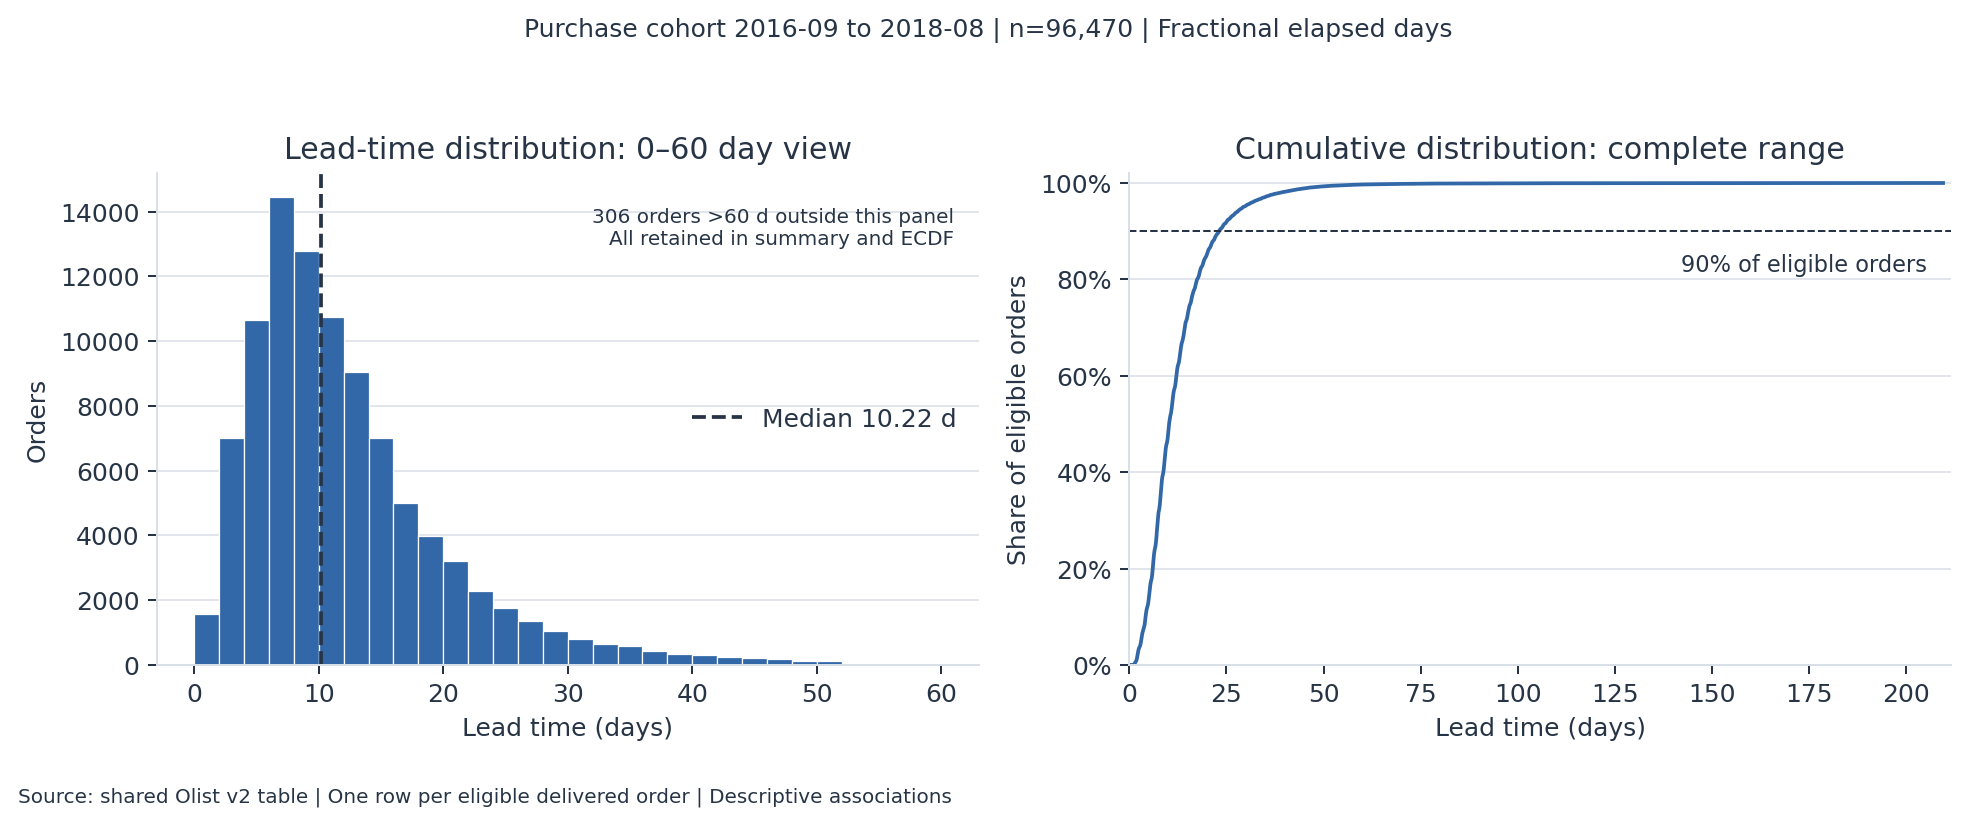

In [8]:
display(tables['sensitivity'])
figure_paths = make_figures(orders,tables,OUTPUT_DIR)
display(Image(filename=str(figure_paths[0])))

**Finding.** The 96,470 eligible orders have mean 12.56 days, median 10.22 and P90 23.10. The mean exceeds the median and the distribution has a long right tail. All 306 orders above 60 days (0.317%) remain in the primary analysis; excluding them reduces the mean to 12.32 days but barely changes the median.

**Handling plan for Phase 2.** Keep valid long deliveries. Use **MAE** as the primary selection criterion, with **RMSE**, median absolute error, P90 absolute error and errors for actual durations above 60 days as secondary diagnostics. The >60-day slice is an outcome-based evaluation slice, never an input feature. Compare raw-target fitting with a `log1p` target and, if appropriate within the chosen model families, robust loss. Select these choices on training/validation data only. Convert predictions back with `expm1` when needed and assess all candidates in original **days**; naive inverse transformation is not guaranteed to estimate the arithmetic mean. Do not choose transformations or cutoffs using test results.

## 3. Which purchase-time attributes merit further investigation?

These are descriptive relationships. They can motivate candidate features but do not identify causal effects, multivariable feature importance or future prediction accuracy.

### 3.1 Geographic relation

,route_group,n,median_days,mean_days,p90_days
0,All sellers same-state,34575,6.551,7.949,14.254
1,Any seller cross-state,61895,12.775,15.133,26.263


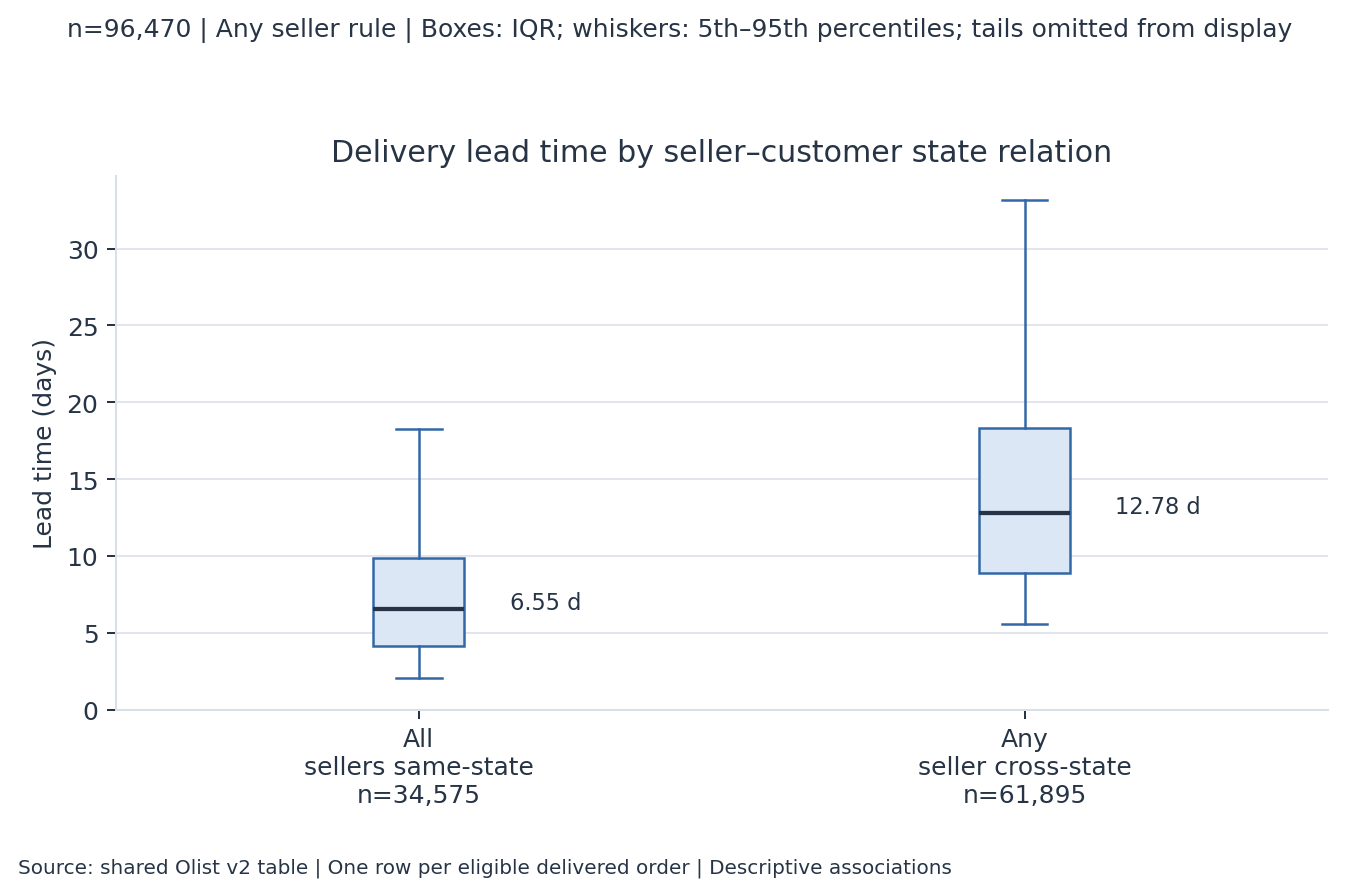

In [9]:
display(tables['route_summary'][['route_group','n','median_days','mean_days','p90_days']])
display(Image(filename=str(figure_paths[1])))

All-sellers-same-state orders have median lead time **6.55 days**, versus **12.78 days** when any seller is cross-state. This shared all/any rule accounts for multi-seller orders. State boundaries are coarse geographic proxies; distance, sellers, products and purchase timing may jointly explain the pattern.

### 3.2 Purchase timing

,purchase_month,n,median_days
3,2017-01,750,10.734
4,2017-02,1653,10.971
5,2017-03,2546,10.126
6,2017-04,2303,12.749
7,2017-05,3545,9.793
8,2017-06,3135,10.805
9,2017-07,3872,10.158
10,2017-08,4193,9.770
11,2017-09,4150,10.314
12,2017-10,4478,10.263


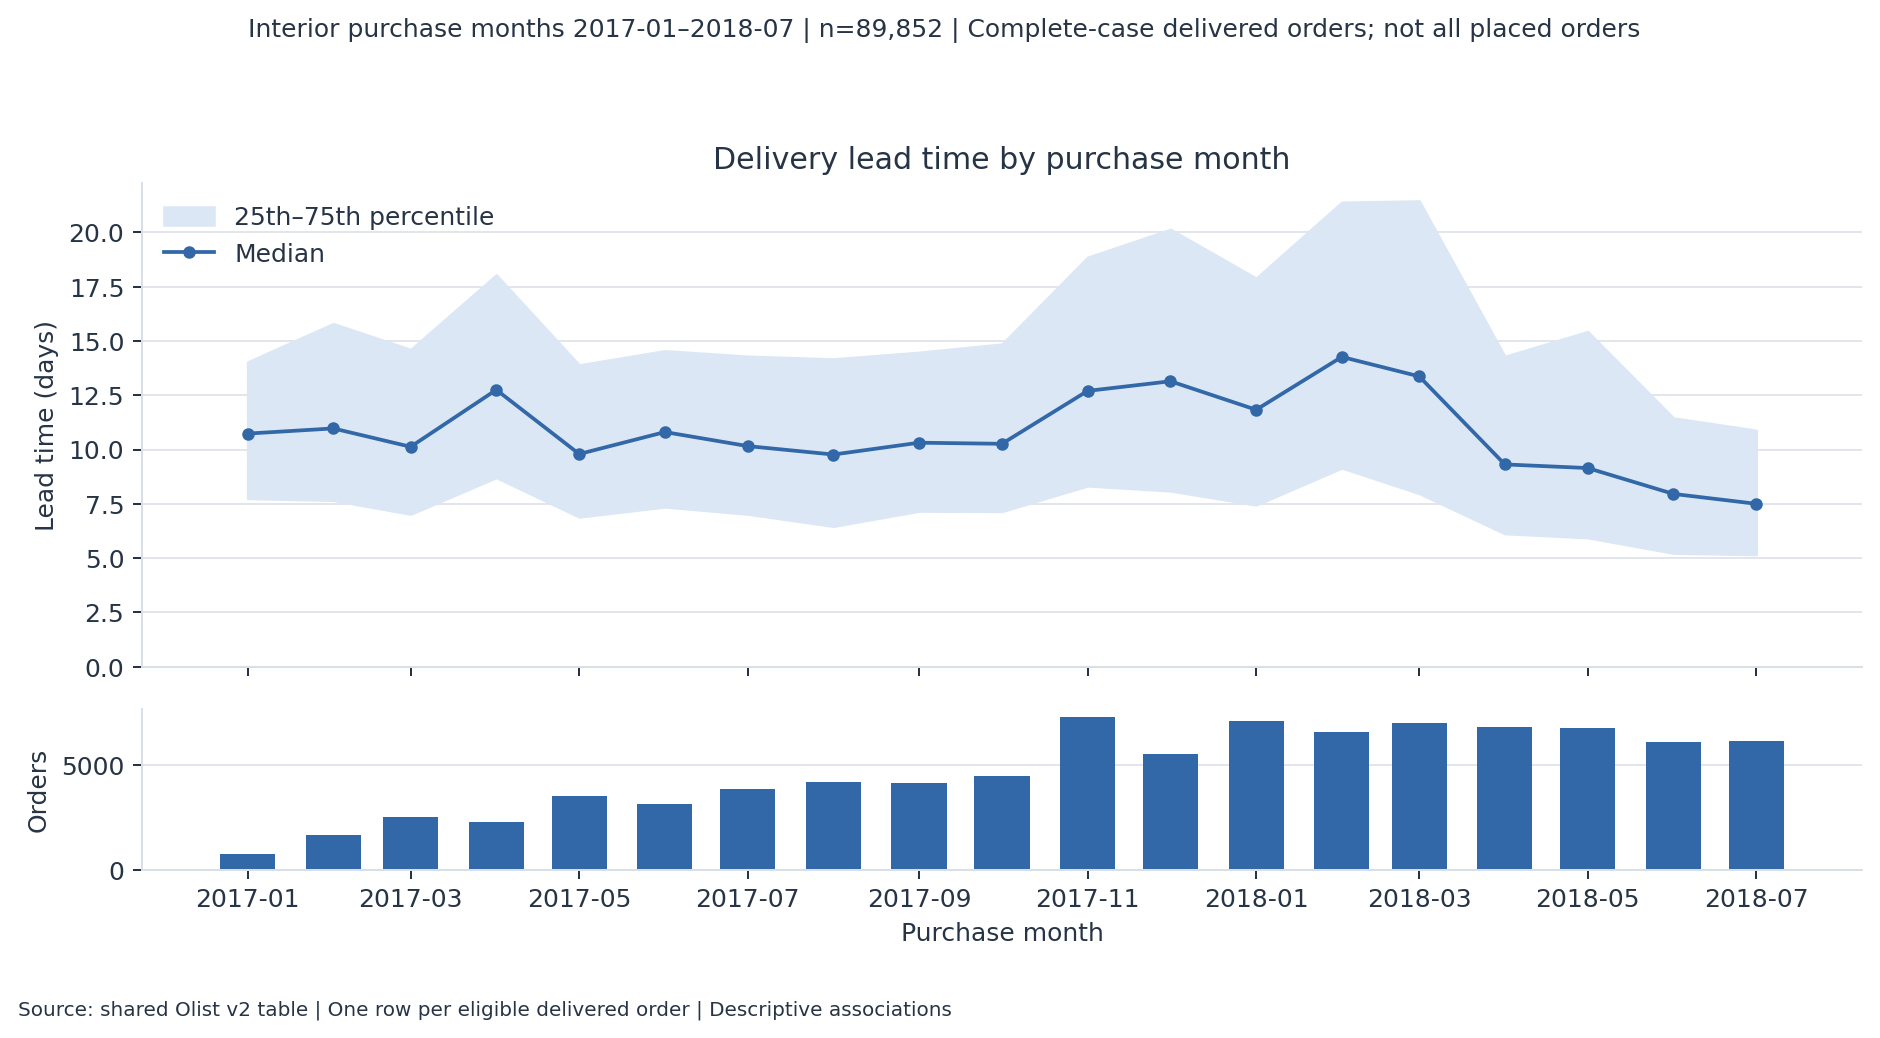

In [10]:
display(tables['monthly_summary'].query('in_plot_window')[['purchase_month','n','median_days']])
display(Image(filename=str(figure_paths[2])))

The median changes from **14.26 days in February 2018** to **7.50 days in July 2018**. This motivates accounting for timing without asserting repeatable seasonality. The displayed window is 2017-01–2018-07 to avoid sparse starting months and the final observation edge; all eligible months remain in the primary statistics and exported table. This restriction does not eliminate all completed-delivery selection effects.

### 3.3 Distance, promise, freight and order contents

,feature,n,missing_orders,spearman_rho
0,max_distance_km,95994,476,0.541
1,promised_lead_time_days,96470,0,0.522
2,total_freight,96470,0,0.382
3,total_price,96470,0,0.102
4,freight_ratio,96470,0,0.121
5,avg_product_weight_g,96448,22,0.094
6,item_count,96470,0,-0.025
7,seller_count,96470,0,-0.048


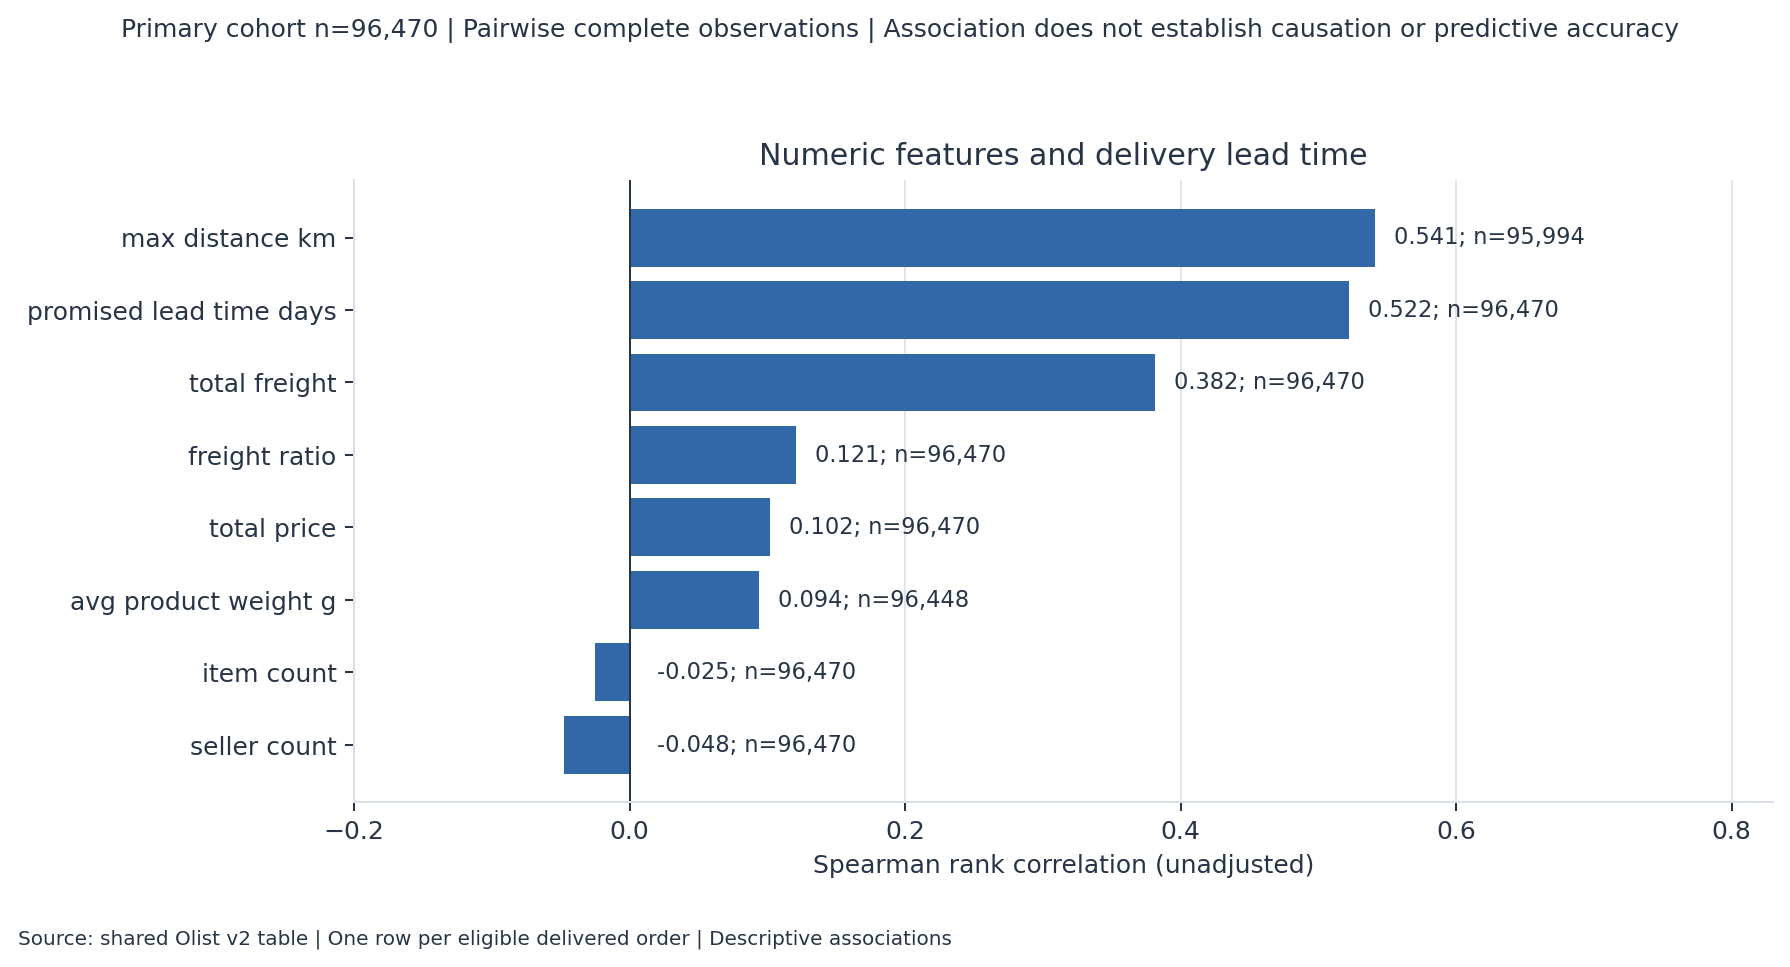

In [11]:
display(tables['numeric_associations'])
display(Image(filename=str(figure_paths[3])))

Maximum observed distance (ρ≈**0.541**) and promised duration (ρ≈**0.522**) are the strongest marginal rank associations among the eight candidates examined; freight follows (ρ≈**0.382**). Distance uses 95,994 observed orders; four of these have only partial item-distance coverage. Complete average weight uses 96,448 orders. Other relationships are weaker; this does not rule out interactions or nonlinear predictive value.

A correlation of 0.52 is not 52% prediction accuracy and does not measure absolute timing error. The promised-duration rule is scored directly in Section 4.

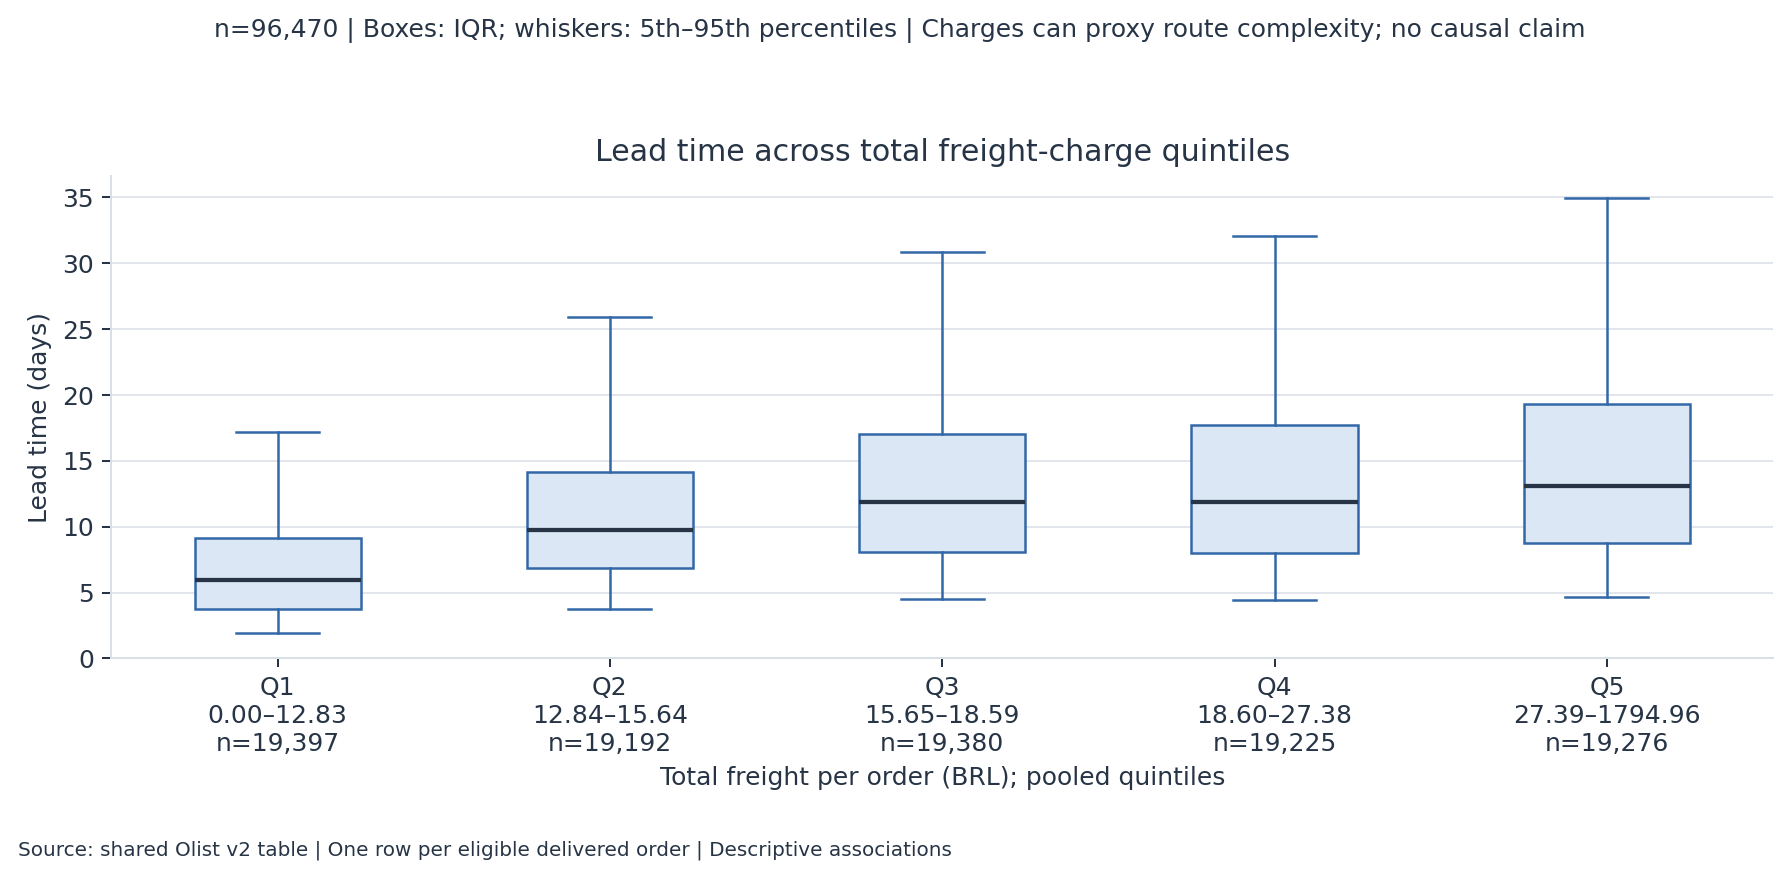

,route_group,feature,n,spearman_rho
0,All sellers same-state,max_distance_km,34514,0.391
1,All sellers same-state,promised_lead_time_days,34575,0.448
2,All sellers same-state,total_freight,34575,0.279
5,Any seller cross-state,max_distance_km,61480,0.290
6,Any seller cross-state,promised_lead_time_days,61895,0.284
7,Any seller cross-state,total_freight,61895,0.121


In [12]:
display(Image(filename=str(figure_paths[4])))
display(tables['associations_within_route'].query("feature in ['max_distance_km','promised_lead_time_days','total_freight']"))

The freight relationship weakens within route groups (same-state ρ≈0.279; cross-state ρ≈0.121). The pooled association partly reflects composition differences, while this simple stratification does not control all confounders.

### 3.4 Major customer states and product groups

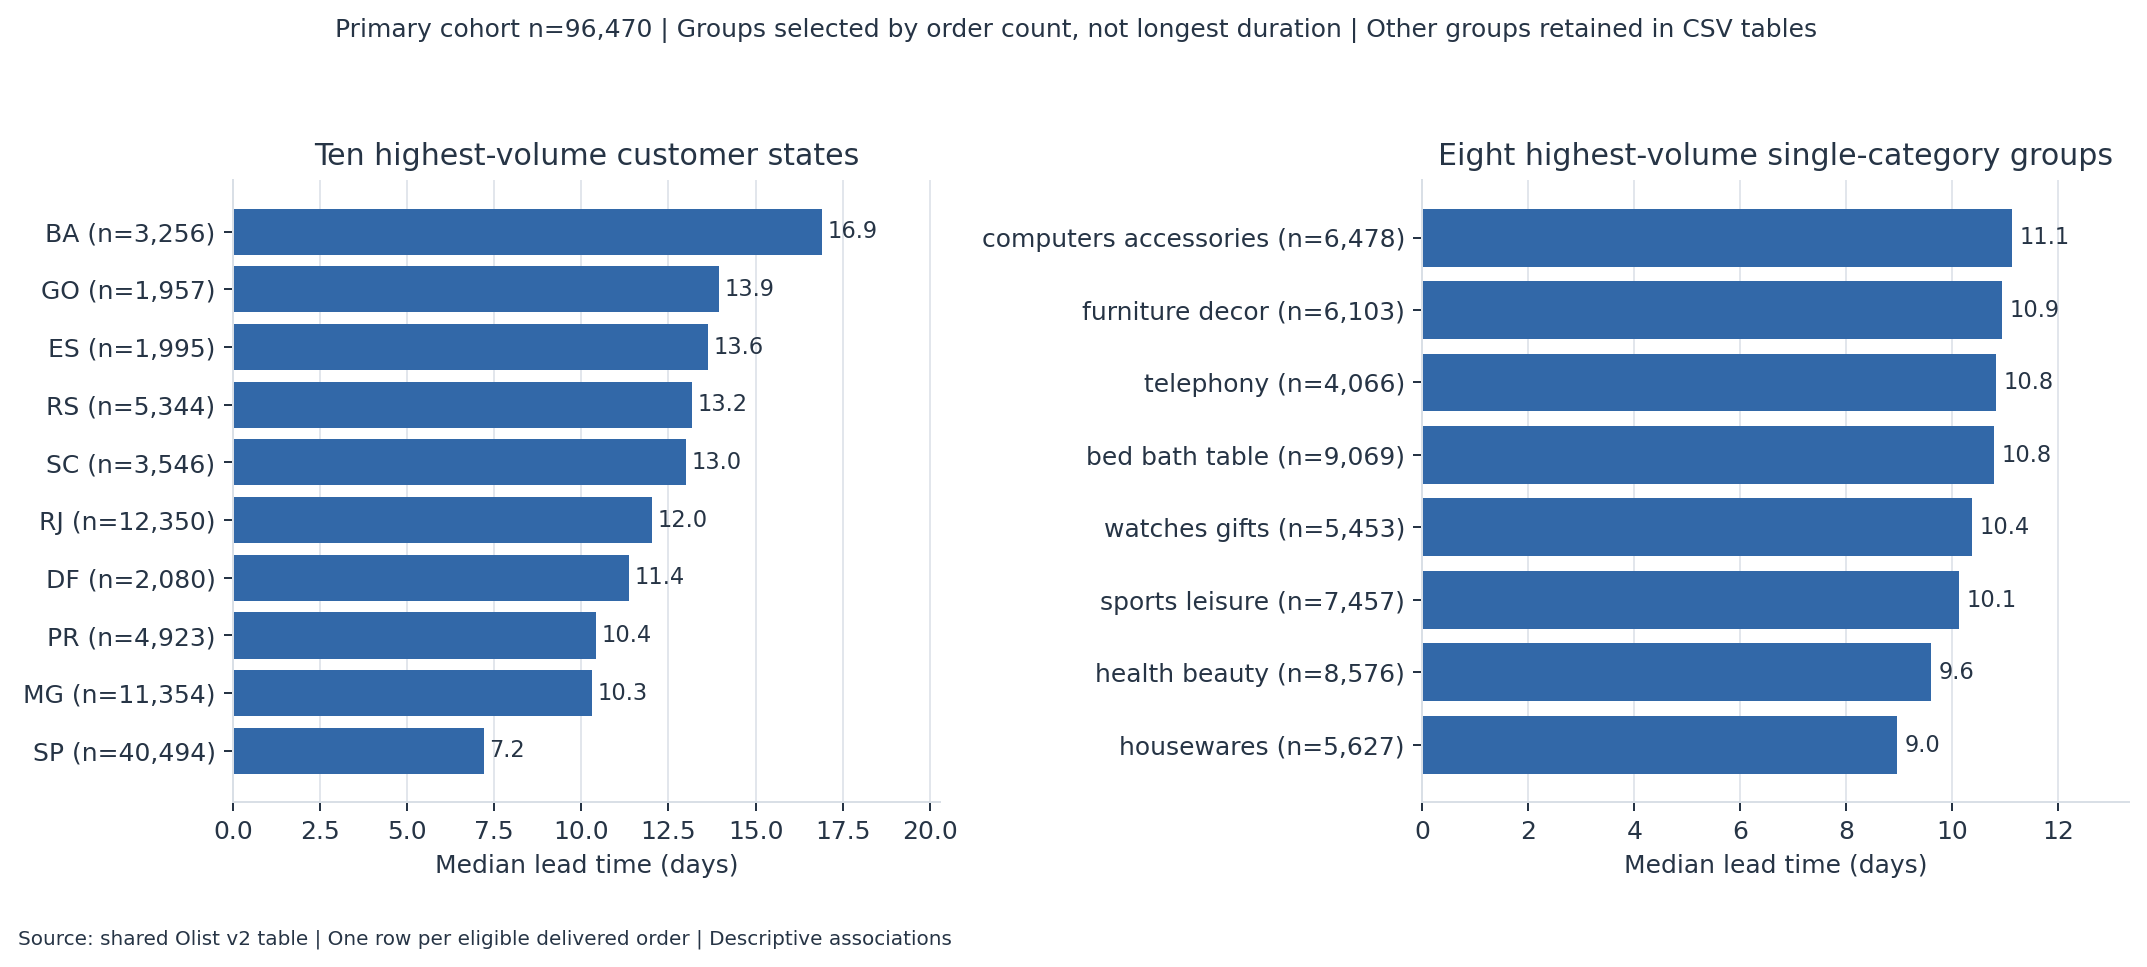

,category_group,n,median_days
9,bed_bath_table,9069,10.781
45,health_beauty,8576,9.600
67,sports_leisure,7457,10.127
17,computers_accessories,6478,11.119
41,furniture_decor,6103,10.937
51,housewares,5627,8.954
72,watches_gifts,5453,10.363
70,telephony,4066,10.825
7,auto,3773,9.747
71,toys,3752,9.436


In [13]:
display(Image(filename=str(figure_paths[5])))
display(tables['category_summary'].nlargest(10,'n')[['category_group','n','median_days']])

Groups are selected by order volume before comparing duration. The category panel includes only complete single-category orders; mixed/incomplete categories remain in the overall sample and complete table. With v2, absent English translations are also missing categories; no Portuguese fallback is reconstructed here.

## 4. Fixed baseline: use promised duration to predict actual duration

For each eligible order, set **predicted actual duration = promised duration**, where both are measured in fractional days from purchase. This is a fixed rule with no fitted parameters. It does not change the prediction target to the promise.

Evaluate on the same primary orders with valid non-negative promised duration. Report MAE, RMSE, median/P90 absolute error and bias (**prediction minus actual**). These are **historical descriptive errors**, not a held-out performance estimate. Positive bias indicates overprediction.

In [14]:
def baseline_metrics(primary):
    """Fixed, untrained predictor: actual elapsed days are predicted by promised elapsed days."""
    valid = primary.promised_lead_time_days.notna() & primary.promised_lead_time_days.ge(0)
    data = primary.loc[valid].copy()
    data['prediction_days'] = data.promised_lead_time_days
    data['error_days'] = data.prediction_days-data.lead_time_days
    data['abs_error_days'] = data.error_days.abs()
    def metrics(part,label):
        errors = part.error_days
        return {'cohort':label,'n':len(part),'mae_days':errors.abs().mean(),
                'rmse_days':np.sqrt(np.square(errors).mean()),
                'median_abs_error_days':errors.abs().median(),
                'p90_abs_error_days':errors.abs().quantile(.9),
                'bias_pred_minus_actual_days':errors.mean()}
    all_metrics = pd.DataFrame([metrics(data,'All eligible primary orders with valid promise')])
    slices = pd.DataFrame([metrics(part,str(name)) for name,part in data.groupby('route_group')]+[
        metrics(data.loc[data.lead_time_days.le(60)],'Actual lead time <=60 days'),
        metrics(data.loc[data.lead_time_days.gt(60)],'Actual lead time >60 days')])
    corr = data[['promised_lead_time_days','lead_time_days']].rank().corr().iloc[0,1]
    info = {'definition':'prediction_days = (estimated delivery - purchase).total_seconds()/86400',
            'evaluation':'Historical descriptive errors; no model trained and no held-out test performed',
            'primary_orders_without_valid_promise':int((~valid).sum()),
            'spearman_rho':float(corr)}
    return data,all_metrics,slices,info


def make_baseline_figure(data,out):
    configure_plots()
    frame=data.copy();frame['promise_group']=pd.qcut(frame.promised_lead_time_days,5,duplicates='drop')
    grouped=frame.groupby('promise_group',observed=True).agg(
        n=('order_id','size'),promise=('prediction_days','median'),actual=('lead_time_days','median'))
    fig,ax=plt.subplots(1,2,figsize=(11,4.5))
    x=np.arange(len(grouped))
    ax[0].plot(x,grouped.promise,marker='s',linestyle='--',color=GOLD,label='Promised duration (prediction)')
    ax[0].plot(x,grouped.actual,marker='o',color=BLUE,label='Actual duration')
    ax[0].set_xticks(x,[f'Q{i+1}\nn={int(n):,}' for i,n in enumerate(grouped.n)])
    ax[0].set(title='Promised vs. actual median duration',xlabel='Quintiles of promised duration',ylabel='Days',ylim=(0,None))
    ax[0].legend(frameon=False,fontsize=8);ax[0].grid(axis='y')
    ax[1].hist(frame.error_days,bins=70,color=BLUE,edgecolor='white',linewidth=.3)
    ax[1].axvline(0,color=INK,linestyle='--',linewidth=1)
    ax[1].set(title='Error when using promised duration as prediction',xlabel='Predicted minus actual days',ylabel='Orders')
    ax[1].text(.97,.93,f'MAE {frame.abs_error_days.mean():.2f} d\nMean overprediction\n{frame.error_days.mean():.2f} d',
               transform=ax[1].transAxes,ha='right',va='top',fontsize=9)
    ax[1].grid(axis='y')
    return save_figure(fig,'07_promised_duration_baseline',
        f'n={len(frame):,} | Untrained rule; historical errors, not future test performance | All valid durations retained',out)

,cohort,n,mae_days,rmse_days,median_abs_error_days,p90_abs_error_days,bias_pred_minus_actual_days
0,All eligible primary orders with valid promise,96470,12.728,15.122,12.172,21.755,11.178


,cohort,n,mae_days,rmse_days,median_abs_error_days,p90_abs_error_days,bias_pred_minus_actual_days
0,All sellers same-state,34575,10.401,12.344,9.592,17.800,9.608
1,Any seller cross-state,61895,14.028,16.471,13.259,23.596,12.055
2,Actual lead time <=60 days,96164,12.586,14.657,12.159,21.450,11.395
3,Actual lead time >60 days,306,57.336,67.641,45.949,109.902,-56.917


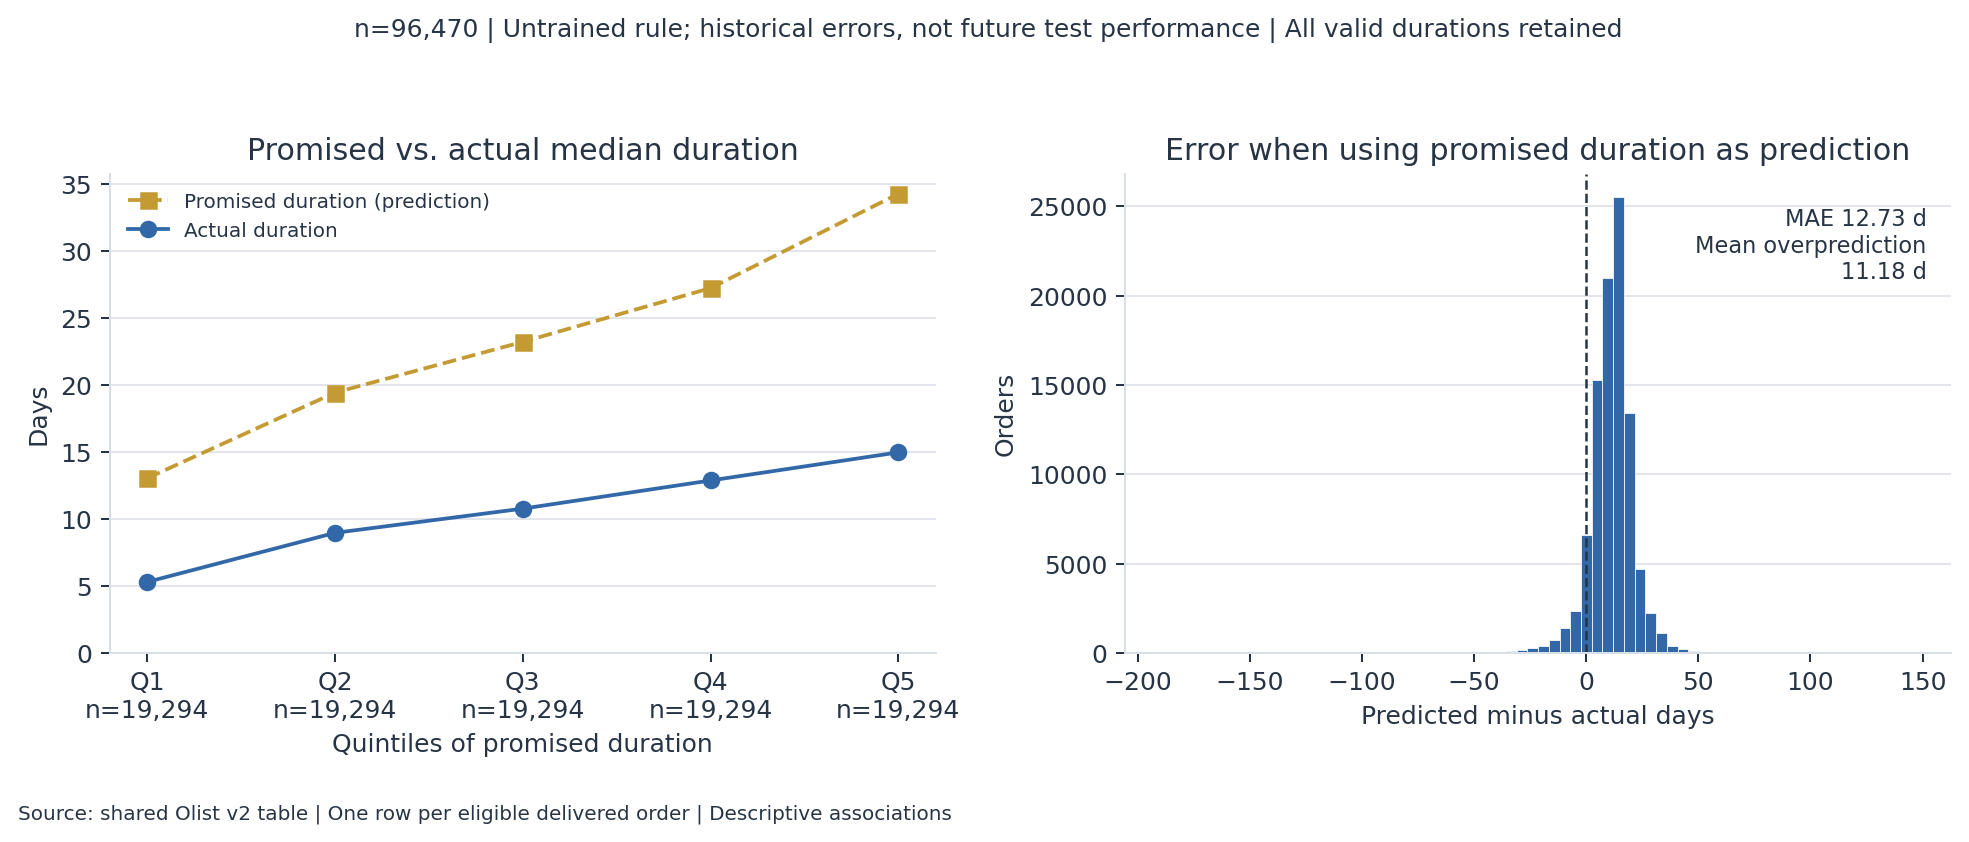

In [15]:
baseline_orders, baseline_summary, baseline_slices, baseline_info = baseline_metrics(orders)
tables['promised_baseline_metrics'] = baseline_summary
tables['promised_baseline_slices'] = baseline_slices
evidence['promised_baseline'] = {**baseline_summary.iloc[0].to_dict(),**baseline_info}
display(baseline_summary)
display(baseline_slices)
figure_paths.append(make_baseline_figure(baseline_orders,OUTPUT_DIR))
display(Image(filename=str(figure_paths[-1])))

**Finding.** All 96,470 primary orders have a valid promise. Directly using it gives historical **MAE 12.73 days**, **RMSE 15.12 days**, median absolute error **12.17 days**, P90 absolute error **21.75 days**, and mean overprediction **11.18 days**. For the 306 actual durations above 60 days, MAE rises to **57.34 days**. The promise has a useful rank association with duration but is frequently longer than realised duration, so association alone does not make it an accurate point estimate.

**Phase 2 success criterion.** Use an untouched, later test period and compare models against this same promise rule on exactly the same eligible test orders, with MAE as the primary criterion and RMSE/tail diagnostics as secondary checks. Also compare train-only mean/median baselines. A model should improve on these references; the all-history MAE above is not a fixed future-test threshold. Promise availability must be preserved as of prediction time.

### Reconcile the shared integer-day reference

`00` reports the approximately +0.52 association using integer-day fields and all observed delivery dates (including six canceled records). The primary regression analysis uses delivered status and fractional days. Both definitions are shown explicitly below, so differences are not hidden by copying a headline coefficient.

In [16]:
definition_rows = []
for label, part, x, y in [
    ('v2 observed dates, any status, integer days',all_orders.loc[all_orders.is_date_observed_cohort],'promised_days','delivery_days'),
    ('Regression primary, fractional days',orders,'promised_lead_time_days','lead_time_days')]:
    pair = part[[x,y]].dropna()
    definition_rows.append({'definition':label,'n':len(pair),'spearman_rho':pair.rank().corr().iloc[0,1]})
tables['time_definition_check'] = pd.DataFrame(definition_rows)
display(tables['time_definition_check'])

,definition,n,spearman_rho
0,"v2 observed dates, any status, integer days",96476,0.521
1,"Regression primary, fractional days",96470,0.522


## 5. Implications and next-stage evaluation

- **Worth pursuing:** the target is derivable, usable inputs exist at purchase time, and geographic, promised-duration, freight and timing associations motivate regression as a candidate problem.
- **No accuracy guarantee:** feature correlations and historical baseline errors do not establish future predictive performance. Candidate features should be evaluated jointly, with missing-distance/weight handling and encoding fitted only on training folds.
- **Validation design:** define the prediction instant, reserve a later test period before further model/feature selection, and examine repeated customers across splits. Use time-respecting validation within the earlier data and state how completed-delivery selection affects the intended use.
- **Long tails:** retain valid targets, choose loss/transformation using validation data, evaluate in days and report tail errors. Do not hide the longest deliveries to improve a score.
- **Coverage:** cancellations and still-undelivered orders are outside the observed target cohort. State this limitation when proposing a customer-facing deployment; the current analysis does not establish performance for those orders.

### Save reproducible evidence

The following exports remain under the configured local output directory. They are audit material, not a model-ready input matrix. The merged v2 and raw data stay outside version control.

In [17]:
def write_outputs(frame,primary,source_path,summary,tables,out=BASE):
    out=Path(out)
    for folder in ['tables','data','figures']:(out/folder).mkdir(exist_ok=True,parents=True)
    for name,table in tables.items():table.to_csv(out/'tables'/f'{name}.csv',index=False)
    primary.drop(columns=['freight_quintile']).to_csv(out/'data/order_level_delivery.csv.gz',index=False,
                                                    compression={'method':'gzip','mtime':0})
    excluded=frame.loc[~frame.is_primary,['order_id','order_status','purchase_ts','delivered_ts','lead_time_days']].copy()
    excluded['exclusion_reason']=np.select([excluded.order_status.ne('delivered'),excluded.lead_time_days.isna()],
        ['Status is not delivered','Missing purchase or delivery time'],default='Negative elapsed time')
    excluded.to_csv(out/'data/excluded_orders.csv',index=False)
    summary['provenance']={'input_filename':Path(source_path).name,
        'input_sha256':hashlib.sha256(Path(source_path).read_bytes()).hexdigest(),
        'source_builder':'00_dataset_overview_eda.ipynb, cells 38-46',
        'reference_commit':SOURCE_COMMIT,
        'runtime_versions':{p:importlib.metadata.version(p) for p in ['pandas','numpy','scipy','matplotlib']},
        'scope':'M1 candidate problem exploration; fixed baseline only, no learned model fitted'}
    pd.DataFrame([{'table':'smartcommerce_consolidated_v2',
                   'filename':Path(source_path).name,
                   'rows':summary['v2_rows'],
                   'columns':len(pd.read_csv(source_path,nrows=0).columns),
                   'orders':summary['v2_orders'],
                   'sha256':summary['provenance']['input_sha256']}]).to_csv(
                       out/'tables/source_inventory.csv',index=False)
    (out/'tables/evidence_summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2,allow_nan=False))

In [18]:
assert orders.order_id.is_unique and len(orders)==96470
assert tables['route_summary'].n.sum()==len(orders)
assert tables['monthly_summary'].n.sum()==len(orders)
assert np.isclose(evidence['primary']['mean_days'],12.558217098051976,atol=1e-9,rtol=0)
assert np.isclose(evidence['promised_baseline']['mae_days'],12.727875875704019,atol=1e-9,rtol=0)
write_outputs(all_orders,orders,V2_PATH,evidence,tables,OUTPUT_DIR)
print('Saved summary tables, primary/excluded order audit data and seven figures to the configured output directory.')

Saved summary tables, primary/excluded order audit data and seven figures to the configured output directory.


## Takeaways

Delivery-duration regression is a supported candidate for M2: distance, the original quoted promise, freight and order timing provide directions to test. The direct-promise rule supplies a concrete benchmark; models must demonstrate improvement on a shared held-out evaluation, including the long tail.

### Sources and AI disclosure

- Shared foundation: [00_dataset_overview_eda.ipynb](https://github.com/IT5006-Group9/IT5006-Group9-Olist-Project/blob/b0bcc909f085945ad41cebaf86581a3f58a050ec/notebooks/00_dataset_overview_eda.ipynb), cells 38–46 (v2 build, role catalogue and common aggregation), cells 48–51 (order-level relationships); source version `b0bcc909f085945ad41cebaf86581a3f58a050ec`.
- The course-provided Olist CSVs supply the underlying observations. Input filename, SHA-256 and package versions are recorded in the generated `tables/evidence_summary.json`.
- [Official IT5006 project briefing](https://prakashsukhwal.github.io/IT5006/IT5006_Project_Description_2026Aug_V2.html#problem-scoping-checklist) supplies the five scoping checks and phase requirements.
- **AI assistance:** Codex assisted with analysis code, figures and explanatory text. The notebook was executed and key data/metric calculations were independently checked. Human review or final submission is not asserted by this statement.